# Interactive noise playground

Weeeee I love noisy play!

In [14]:
from matplotlib import pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of asset_dist.grass failed: Traceback (most recent call last):
  File "/home/s481827/.conda/envs/env_isaaclab/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/s481827/.conda/envs/env_isaaclab/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/home/s481827/.conda/envs/env_isaaclab/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 883, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/projects/neuroforgelab/dev/forest-gen/src/forest_gen/asset_dist/grass.py", line 3, in <module>
    from ..heightmap import normalized_noise2
ImportError: attempted relative import beyond top-level package
]


In [15]:
import sys
sys.path.append("src/forest_gen")

In [16]:
from asset_dist import classify_terrain

width = 100
height = 100
resolution = 500

x = np.linspace(0, width, resolution)
y = np.linspace(0, height, resolution)
xx, yy = np.meshgrid(x, y)

vec_classify = np.vectorize(classify_terrain)
terrain = vec_classify(xx, yy)

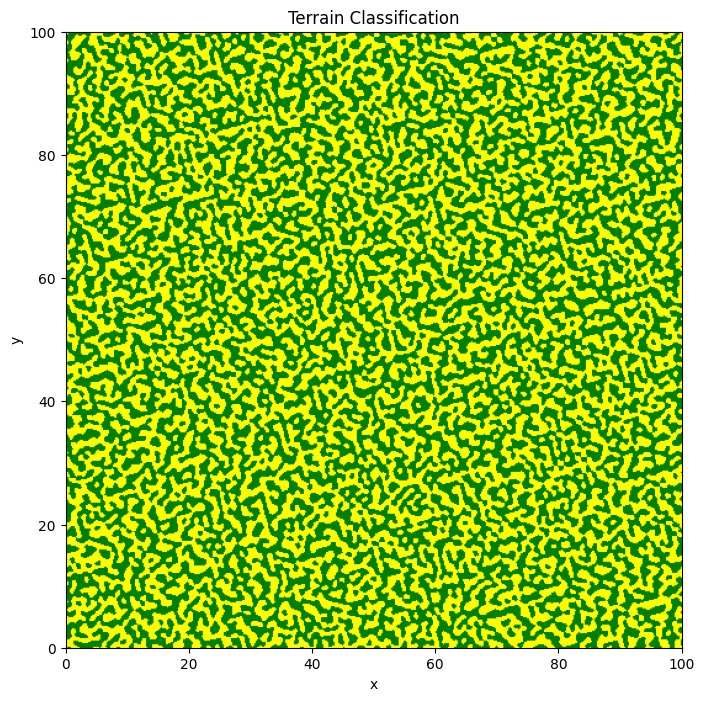

In [17]:
terrain_map = {"forest": 0, "plain": 1}
terrain_int = np.vectorize(terrain_map.get)(terrain)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["green", "yellow"])

plt.figure(figsize=(8, 8))
plt.imshow(terrain_int, origin="lower", extent=(x.min(), x.max(), y.min(), y.max()), cmap=cmap)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain Classification")
plt.show()

In [18]:
from asset_dist import grass_distribution

grass_final = grass_distribution(width, height)

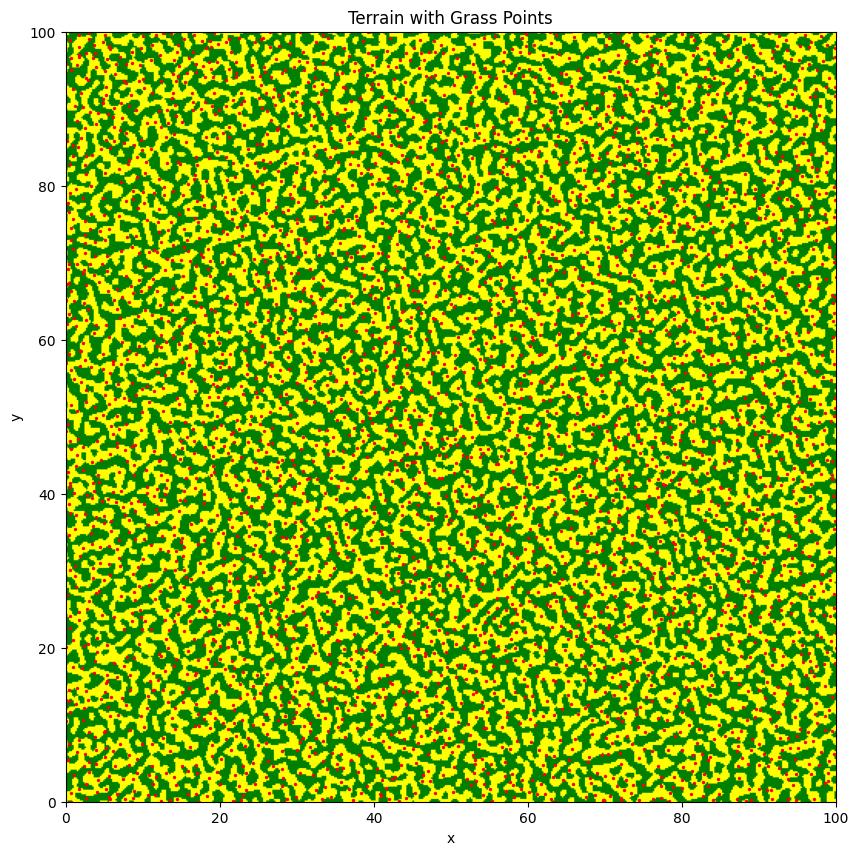

In [19]:
grass_x, grass_y = zip(*grass_final) if grass_final else ([], [])

plt.figure(figsize=(10, 10))
plt.imshow(terrain_int, origin="lower", extent=(x.min(), x.max(), y.min(), y.max()), cmap=cmap)
plt.scatter(grass_x, grass_y, s=2, c="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain with Grass Points")
plt.show()